<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/20260526_Detector_%20toy_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,n_detectors,n_baselines,galaxies_baseline_only,galaxies_baseline_plus_snr
0,3,3,374.000000,374.000000
1,4,6,187.000000,121.460063
2,5,10,112.200000,52.145848
3,6,15,74.800000,26.445794
4,7,21,53.428571,14.990233
5,8,28,40.071429,9.201989
6,9,36,31.166667,5.998028
7,10,45,24.933333,4.096965
8,11,55,20.400000,2.905514
9,12,66,17.000000,2.125000


,n_detectors,n_baselines,galaxies_baseline_only,galaxies_baseline_plus_snr
36,39,741,1.514170,0.032304
37,40,780,1.438462,0.029545
38,41,820,1.368293,0.027082
39,42,861,1.303136,0.024877
40,43,903,1.242525,0.022897
41,44,946,1.186047,0.021116
42,45,990,1.133333,0.019508
43,46,1035,1.084058,0.018055
44,47,1081,1.037928,0.016738
45,48,1128,0.994681,0.015542


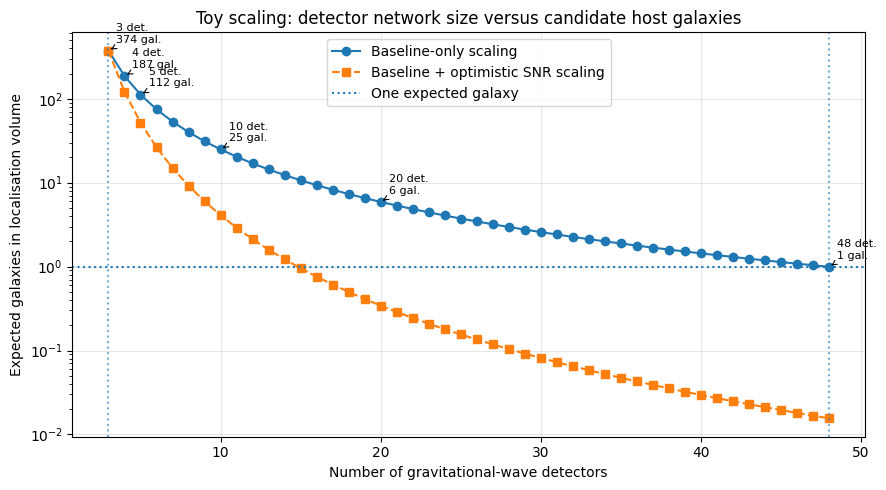

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Toy model: expected number of galaxies versus detector count
# ------------------------------------------------------------
# Reference point:
# From the GW190814-like EAGLE/observed-like volume work:
# ~374 galaxies in a 3-detector GW190814-like localisation volume.

N_ref = 3
galaxies_ref = 374

def n_baselines(N):
    """Number of pairwise baselines for N detectors."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector counts to test
N_values = np.arange(3, 49)

# ------------------------------------------------------------
# Model 1: conservative baseline-only scaling
# ------------------------------------------------------------
# Assumption:
#   localisation volume ∝ 1 / number of baselines
#
# Therefore:
#   N_gal(N) = N_gal(3) * B_3 / B_N

galaxies_baseline_only = galaxies_ref * (B_ref / n_baselines(N_values))

# ------------------------------------------------------------
# Model 2: optimistic baseline + network-SNR scaling
# ------------------------------------------------------------
# Assumptions:
#   network SNR ∝ sqrt(N / 3)
#   localisation volume ∝ SNR^(-3)
#   localisation also improves with number of baselines
#
# Therefore:
#   improvement factor =
#       (B_N / B_3) * (N / 3)^(3/2)
#
# This is intentionally optimistic and should not be treated
# as a detector-network forecast.

snr_factor = (N_values / N_ref) ** 0.5

galaxies_baseline_plus_snr = galaxies_ref / (
    (n_baselines(N_values) / B_ref) * snr_factor**3
)

# ------------------------------------------------------------
# Put values into a table
# ------------------------------------------------------------

toy_table = pd.DataFrame({
    "n_detectors": N_values,
    "n_baselines": n_baselines(N_values).astype(int),
    "galaxies_baseline_only": galaxies_baseline_only,
    "galaxies_baseline_plus_snr": galaxies_baseline_plus_snr,
})

display(toy_table.head(15))
display(toy_table.tail(10))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    N_values,
    galaxies_baseline_only,
    marker="o",
    label="Baseline-only scaling"
)

plt.plot(
    N_values,
    galaxies_baseline_plus_snr,
    marker="s",
    linestyle="--",
    label="Baseline + optimistic SNR scaling"
)

# Reference lines
plt.axhline(
    1,
    linestyle=":",
    label="One expected galaxy"
)

plt.axvline(
    3,
    linestyle=":",
    alpha=0.6
)

plt.axvline(
    48,
    linestyle=":",
    alpha=0.6
)

# Annotate key points for baseline-only model
key_points = [3, 4, 5, 10, 20, 48]

for N in key_points:
    y = galaxies_ref * (B_ref / n_baselines(N))
    plt.annotate(
        f"{N} det.\n{y:.0f} gal.",
        xy=(N, y),
        xytext=(N + 0.5, y * 1.25),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", lw=0.8)
    )

plt.yscale("log")
plt.xlabel("Number of gravitational-wave detectors")
plt.ylabel("Expected galaxies in localisation volume")
plt.title("Toy scaling: detector network size versus candidate host galaxies")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

First detector/node count reaching <= 1 expected galaxy:


,snr_uplift,first_n_with_expected_galaxies_leq_1,baselines_at_threshold,expected_galaxies_at_threshold
0,1,48,1128,0.994681
1,2,18,153,0.916667
2,3,10,45,0.923457
3,5,5,10,0.897600
4,10,3,3,0.374000



Expected galaxies for selected detector/node counts:


,k_snr=1,k_snr=2,k_snr=3,k_snr=5,k_snr=10
n_detectors_or_nodes,,,,,
3,374.000000,46.750000,13.851852,2.992000,0.374000
4,187.000000,23.375000,6.925926,1.496000,0.187000
5,112.200000,14.025000,4.155556,0.897600,0.112200
10,24.933333,3.116667,0.923457,0.199467,0.024933
20,5.905263,0.738158,0.218713,0.047242,0.005905
48,0.994681,0.124335,0.036840,0.007957,0.000995


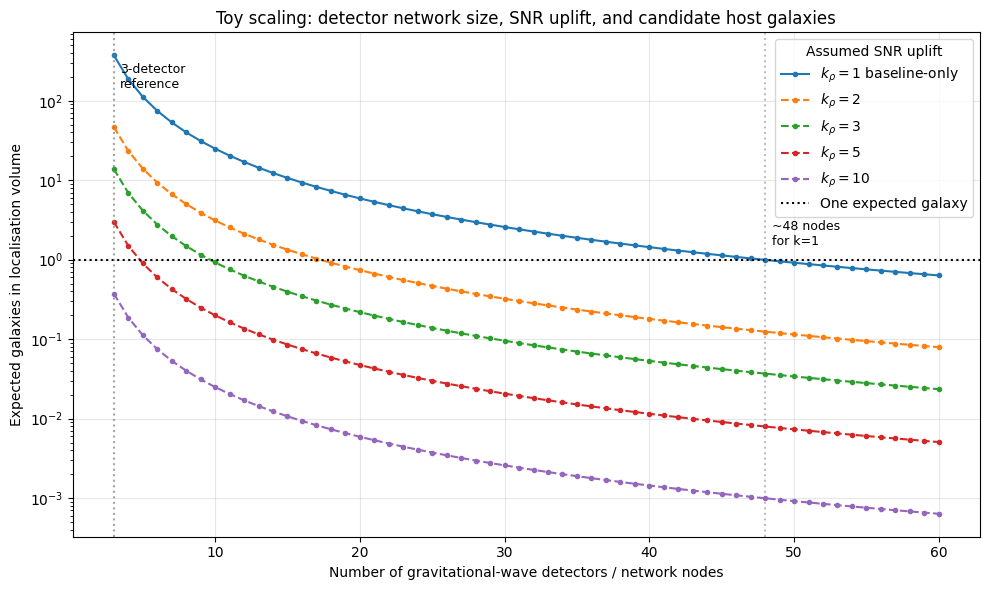

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ------------------------------------------------------------
# Toy model: expected number of galaxies versus detector count
# with different assumed SNR uplift factors
# ------------------------------------------------------------

# Reference point from GW190814-like volume work:
# ~374 observed-like galaxies in a 3-detector localisation volume
N_ref = 3
galaxies_ref = 374

def n_baselines(N):
    """Number of pairwise baselines for N detectors/nodes."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector/node counts to explore
N_values = np.arange(3, 61)

# Assumed SNR uplifts relative to GW190814-like reference case
snr_uplifts = [1, 2, 3, 5, 10]

# Optional:
# If True, also assumes that adding more detectors increases network SNR as sqrt(N/3).
# I recommend leaving this False for the cleanest toy model, otherwise you may double-count.
INCLUDE_NETWORK_SNR_FROM_MORE_DETECTORS = False

rows = []

for k_snr in snr_uplifts:
    if INCLUDE_NETWORK_SNR_FROM_MORE_DETECTORS:
        network_snr_factor = np.sqrt(N_values / N_ref)
    else:
        network_snr_factor = np.ones_like(N_values, dtype=float)

    total_snr_factor = k_snr * network_snr_factor

    galaxies_expected = galaxies_ref / (
        (n_baselines(N_values) / B_ref) * total_snr_factor**3
    )

    for N, B, ngal in zip(N_values, n_baselines(N_values), galaxies_expected):
        rows.append({
            "n_detectors_or_nodes": N,
            "n_baselines": int(B),
            "snr_uplift": k_snr,
            "expected_galaxies": ngal,
        })

toy_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Find first detector/node count where expected galaxies <= 1
# ------------------------------------------------------------

threshold_rows = []

for k_snr in snr_uplifts:
    sub = toy_df[toy_df["snr_uplift"] == k_snr].copy()
    below = sub[sub["expected_galaxies"] <= 1]

    if len(below) > 0:
        first = below.iloc[0]
        threshold_rows.append({
            "snr_uplift": k_snr,
            "first_n_with_expected_galaxies_leq_1": int(first["n_detectors_or_nodes"]),
            "baselines_at_threshold": int(first["n_baselines"]),
            "expected_galaxies_at_threshold": first["expected_galaxies"],
        })
    else:
        threshold_rows.append({
            "snr_uplift": k_snr,
            "first_n_with_expected_galaxies_leq_1": np.nan,
            "baselines_at_threshold": np.nan,
            "expected_galaxies_at_threshold": np.nan,
        })

threshold_df = pd.DataFrame(threshold_rows)

print("First detector/node count reaching <= 1 expected galaxy:")
display(threshold_df)

# Show selected values for intuition
selected_N = [3, 4, 5, 10, 20, 48]

selected_table = (
    toy_df[toy_df["n_detectors_or_nodes"].isin(selected_N)]
    .pivot(
        index="n_detectors_or_nodes",
        columns="snr_uplift",
        values="expected_galaxies"
    )
)

selected_table.columns = [f"k_snr={c}" for c in selected_table.columns]

print("\nExpected galaxies for selected detector/node counts:")
display(selected_table)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for k_snr in snr_uplifts:
    sub = toy_df[toy_df["snr_uplift"] == k_snr]

    if k_snr == 1:
        label = r"$k_\rho=1$ baseline-only"
        linestyle = "-"
    else:
        label = fr"$k_\rho={k_snr}$"
        linestyle = "--"

    plt.plot(
        sub["n_detectors_or_nodes"],
        sub["expected_galaxies"],
        marker="o",
        markersize=3,
        linestyle=linestyle,
        label=label
    )

# Reference: one expected galaxy
plt.axhline(
    1,
    linestyle=":",
    color="black",
    linewidth=1.5,
    label="One expected galaxy"
)

# Reference: current 3-detector baseline
plt.axvline(
    3,
    linestyle=":",
    color="gray",
    alpha=0.7
)

plt.text(
    3.4,
    galaxies_ref * 0.8,
    "3-detector\nreference",
    fontsize=9,
    va="top"
)

# Annotate the k=1 threshold around 48 detectors
plt.axvline(
    48,
    linestyle=":",
    color="gray",
    alpha=0.5
)

plt.text(
    48.5,
    1.4,
    "~48 nodes\nfor k=1",
    fontsize=9,
    va="bottom"
)

plt.yscale("log")
plt.xlabel("Number of gravitational-wave detectors / network nodes")
plt.ylabel("Expected galaxies in localisation volume")
plt.title("Toy scaling: detector network size, SNR uplift, and candidate host galaxies")
plt.grid(alpha=0.3)
plt.legend(title="Assumed SNR uplift")

plt.tight_layout()
plt.show()

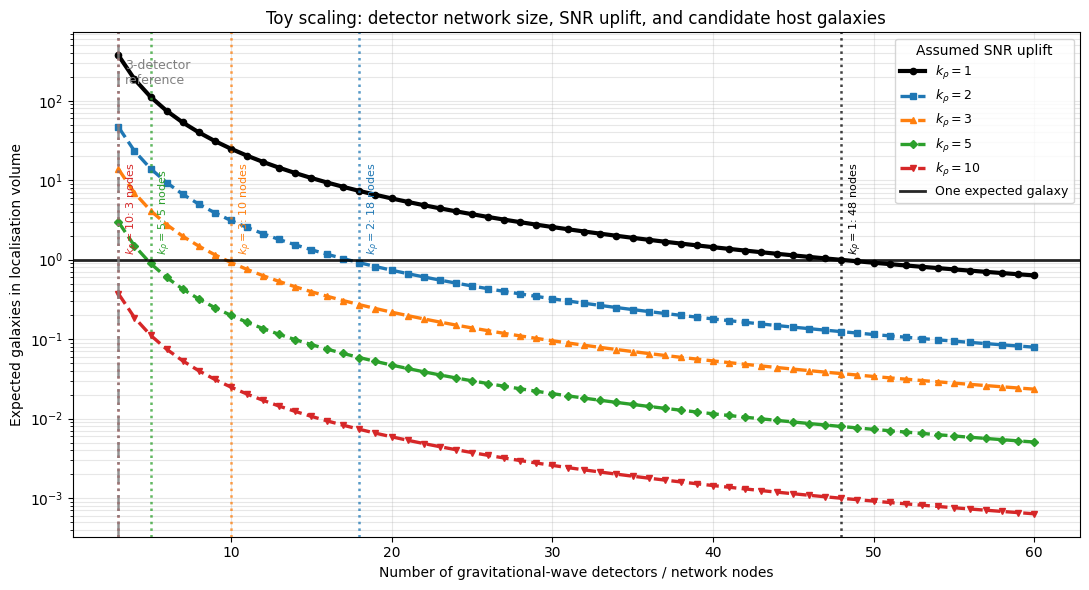

In [2]:
# ------------------------------------------------------------
# Plot: darker curves + one-galaxy threshold lines for each k_snr
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))
ax = plt.gca()

# Darker, high-contrast colours
curve_styles = {
    1:  {"color": "black",      "linewidth": 3.0, "linestyle": "-",  "marker": "o"},
    2:  {"color": "tab:blue",   "linewidth": 2.4, "linestyle": "--", "marker": "s"},
    3:  {"color": "tab:orange", "linewidth": 2.4, "linestyle": "--", "marker": "^"},
    5:  {"color": "tab:green",  "linewidth": 2.4, "linestyle": "--", "marker": "D"},
    10: {"color": "tab:red",    "linewidth": 2.4, "linestyle": "--", "marker": "v"},
}

for k_snr in snr_uplifts:
    sub = toy_df[toy_df["snr_uplift"] == k_snr].copy()
    style = curve_styles[k_snr]

    label = fr"$k_\rho={k_snr}$"

    ax.plot(
        sub["n_detectors_or_nodes"],
        sub["expected_galaxies"],
        color=style["color"],
        linewidth=style["linewidth"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markersize=4.5,
        label=label
    )

    # Find first detector/node count where expected galaxies <= 1
    below_one = sub[sub["expected_galaxies"] <= 1]

    if len(below_one) > 0:
        first = below_one.iloc[0]
        n_thresh = first["n_detectors_or_nodes"]

        # Vertical threshold line for this curve
        ax.axvline(
            n_thresh,
            color=style["color"],
            linestyle=":",
            linewidth=1.8,
            alpha=0.75
        )

        # Annotation near the one-galaxy line
        ax.text(
            n_thresh + 0.4,
            1.15,
            fr"$k_\rho={k_snr}$: {int(n_thresh)} nodes",
            color=style["color"],
            fontsize=8,
            rotation=90,
            va="bottom",
            ha="left"
        )

# Horizontal one-galaxy threshold
ax.axhline(
    1,
    linestyle="-",
    color="black",
    linewidth=2.0,
    alpha=0.85,
    label="One expected galaxy"
)

# Current 3-detector reference
ax.axvline(
    3,
    linestyle="-.",
    color="gray",
    linewidth=1.8,
    alpha=0.85
)

ax.text(
    3.4,
    galaxies_ref * 0.9,
    "3-detector\nreference",
    fontsize=9,
    color="gray",
    va="top"
)

ax.set_yscale("log")
ax.set_xlabel("Number of gravitational-wave detectors / network nodes")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title("Toy scaling: detector network size, SNR uplift, and candidate host galaxies")

ax.grid(alpha=0.3, which="both")
ax.legend(title="Assumed SNR uplift", fontsize=9)

plt.tight_layout()
plt.show()

First detector-site count reaching <= 1 expected galaxy:


,scenario,k_B,k_Q,first_n_detectors_for_leq_1_galaxy,baselines_at_threshold,expected_galaxies_at_threshold
0,Baseline only,1.0,1.0,48,1128,0.994681
1,Mild geometry gain: $k_B=1.5$,1.5,1.0,33,528,0.944444
2,Mild distance-degeneracy gain: $k_Q=2$,1.0,2.0,34,561,1.000000
3,"Combined moderate gain: $k_B=1.5,\ k_Q=2$",1.5,2.0,23,253,0.985507
4,"Optimistic non-SNR gain: $k_B=2,\ k_Q=3$",2.0,3.0,15,105,0.890476



Expected galaxies for selected detector-site counts:


scenario,Baseline only,"Combined moderate gain: $k_B=1.5,\ k_Q=2$",Mild distance-degeneracy gain: $k_Q=2$,Mild geometry gain: $k_B=1.5$,"Optimistic non-SNR gain: $k_B=2,\ k_Q=3$"
n_detectors,,,,,
3,374.000000,83.111111,187.000000,166.222222,31.166667
4,187.000000,41.555556,93.500000,83.111111,15.583333
5,112.200000,24.933333,56.100000,49.866667,9.350000
10,24.933333,5.540741,12.466667,11.081481,2.077778
20,5.905263,1.312281,2.952632,2.624561,0.492105
30,2.579310,0.573180,1.289655,1.146360,0.214943
40,1.438462,0.319658,0.719231,0.639316,0.119872
48,0.994681,0.221040,0.497340,0.442080,0.082890


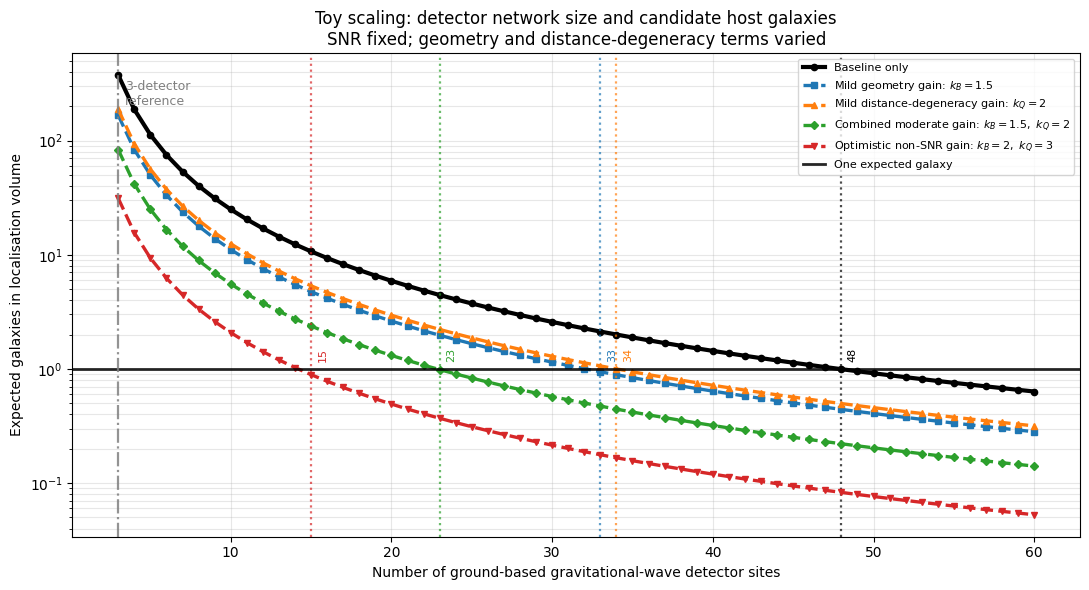

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================
# Earth-based toy model with geometry + distance-degeneracy terms
# SNR is fixed: k_rho = 1
# ============================================================

# Reference case:
# GW190814-like localisation volume with ~374 observed-like galaxies
N_ref = 3
galaxies_ref = 374

def n_baselines(N):
    """Number of pairwise baselines for N ground-based detector sites."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector-site counts to test
N_values = np.arange(3, 61)

# SNR uplift fixed to 1: no SNR improvement
k_rho = 1.0

# ------------------------------------------------------------
# Scenario definitions
# ------------------------------------------------------------
# k_B = effective baseline / sky-geometry improvement factor
# k_Q = distance / inclination / polarisation degeneracy-breaking factor
#
# These are not measured values. They are toy parameters.
#
# Total improvement:
# I_loc = k_rho^3 * k_B^2 * k_G * k_Q

scenarios = [
    {
        "name": "Baseline only",
        "k_B": 1.0,
        "k_Q": 1.0,
        "color": "black",
        "linestyle": "-",
        "linewidth": 3.0,
        "marker": "o",
    },
    {
        "name": r"Mild geometry gain: $k_B=1.5$",
        "k_B": 1.5,
        "k_Q": 1.0,
        "color": "tab:blue",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "s",
    },
    {
        "name": r"Mild distance-degeneracy gain: $k_Q=2$",
        "k_B": 1.0,
        "k_Q": 2.0,
        "color": "tab:orange",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "^",
    },
    {
        "name": r"Combined moderate gain: $k_B=1.5,\ k_Q=2$",
        "k_B": 1.5,
        "k_Q": 2.0,
        "color": "tab:green",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "D",
    },
    {
        "name": r"Optimistic non-SNR gain: $k_B=2,\ k_Q=3$",
        "k_B": 2.0,
        "k_Q": 3.0,
        "color": "tab:red",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "v",
    },
]

# ------------------------------------------------------------
# Compute expected galaxy counts
# ------------------------------------------------------------

rows = []

for scenario in scenarios:
    k_B = scenario["k_B"]
    k_Q = scenario["k_Q"]

    for N in N_values:
        B_N = n_baselines(N)
        k_G = B_N / B_ref

        I_loc = (k_rho ** 3) * (k_B ** 2) * k_G * k_Q

        expected_galaxies = galaxies_ref / I_loc

        rows.append({
            "scenario": scenario["name"],
            "n_detectors": N,
            "n_baselines": int(B_N),
            "k_rho": k_rho,
            "k_B": k_B,
            "k_Q": k_Q,
            "k_G": k_G,
            "I_loc": I_loc,
            "expected_galaxies": expected_galaxies,
        })

toy_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Threshold table: first detector count with <= 1 expected galaxy
# ------------------------------------------------------------

threshold_rows = []

for scenario in scenarios:
    name = scenario["name"]
    sub = toy_df[toy_df["scenario"] == name].copy()
    below = sub[sub["expected_galaxies"] <= 1]

    if len(below) > 0:
        first = below.iloc[0]
        threshold_rows.append({
            "scenario": name,
            "k_B": first["k_B"],
            "k_Q": first["k_Q"],
            "first_n_detectors_for_leq_1_galaxy": int(first["n_detectors"]),
            "baselines_at_threshold": int(first["n_baselines"]),
            "expected_galaxies_at_threshold": first["expected_galaxies"],
        })
    else:
        threshold_rows.append({
            "scenario": name,
            "k_B": scenario["k_B"],
            "k_Q": scenario["k_Q"],
            "first_n_detectors_for_leq_1_galaxy": np.nan,
            "baselines_at_threshold": np.nan,
            "expected_galaxies_at_threshold": np.nan,
        })

threshold_df = pd.DataFrame(threshold_rows)

print("First detector-site count reaching <= 1 expected galaxy:")
display(threshold_df)

# ------------------------------------------------------------
# Selected detector counts table
# ------------------------------------------------------------

selected_N = [3, 4, 5, 10, 20, 30, 40, 48]

selected_table = (
    toy_df[toy_df["n_detectors"].isin(selected_N)]
    .pivot(
        index="n_detectors",
        columns="scenario",
        values="expected_galaxies"
    )
)

print("\nExpected galaxies for selected detector-site counts:")
display(selected_table)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))
ax = plt.gca()

for scenario in scenarios:
    name = scenario["name"]
    sub = toy_df[toy_df["scenario"] == name].copy()

    ax.plot(
        sub["n_detectors"],
        sub["expected_galaxies"],
        color=scenario["color"],
        linestyle=scenario["linestyle"],
        linewidth=scenario["linewidth"],
        marker=scenario["marker"],
        markersize=4.5,
        label=name
    )

    # Annotate first <= 1 galaxy threshold
    below_one = sub[sub["expected_galaxies"] <= 1]

    if len(below_one) > 0:
        first = below_one.iloc[0]
        n_thresh = first["n_detectors"]

        ax.axvline(
            n_thresh,
            color=scenario["color"],
            linestyle=":",
            linewidth=1.6,
            alpha=0.7
        )

        ax.text(
            n_thresh + 0.4,
            1.15,
            f"{int(n_thresh)}",
            color=scenario["color"],
            fontsize=8,
            rotation=90,
            va="bottom",
            ha="left"
        )

# One-galaxy line
ax.axhline(
    1,
    color="black",
    linestyle="-",
    linewidth=2.0,
    alpha=0.85,
    label="One expected galaxy"
)

# Reference 3-detector line
ax.axvline(
    3,
    color="gray",
    linestyle="-.",
    linewidth=1.6,
    alpha=0.85
)

ax.text(
    3.4,
    galaxies_ref * 0.9,
    "3-detector\nreference",
    fontsize=9,
    color="gray",
    va="top"
)

ax.set_yscale("log")
ax.set_xlabel("Number of ground-based gravitational-wave detector sites")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title("Toy scaling: detector network size and candidate host galaxies\nSNR fixed; geometry and distance-degeneracy terms varied")

ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

First detector-site count reaching <= 1 expected galaxy:


,alpha,first_n_detector_sites_for_leq_1_galaxy,baselines_at_threshold,expected_galaxies_at_threshold
0,1.00,48,1128,0.994681
1,1.25,27,351,0.971940
2,1.50,19,171,0.869079
3,1.75,14,91,0.953919
4,2.00,12,66,0.772727



Expected galaxies for selected detector-site counts:


,alpha=1.0,alpha=1.25,alpha=1.5,alpha=1.75,alpha=2.0
n_detector_sites,,,,,
3,374.000000,374.000000,374.000000,374.000000,374.000000
4,187.000000,157.247630,132.228968,111.190865,93.500000
5,112.200000,83.037291,61.454471,45.481397,33.660000
10,24.933333,12.669443,6.437759,3.271236,1.662222
15,10.685714,4.393256,1.806215,0.742596,0.305306
20,5.905263,2.093299,0.742033,0.263036,0.093241
30,2.579310,0.743296,0.214200,0.061727,0.017788
40,1.438462,0.358224,0.089210,0.022216,0.005533
48,0.994681,0.225885,0.051297,0.011649,0.002645


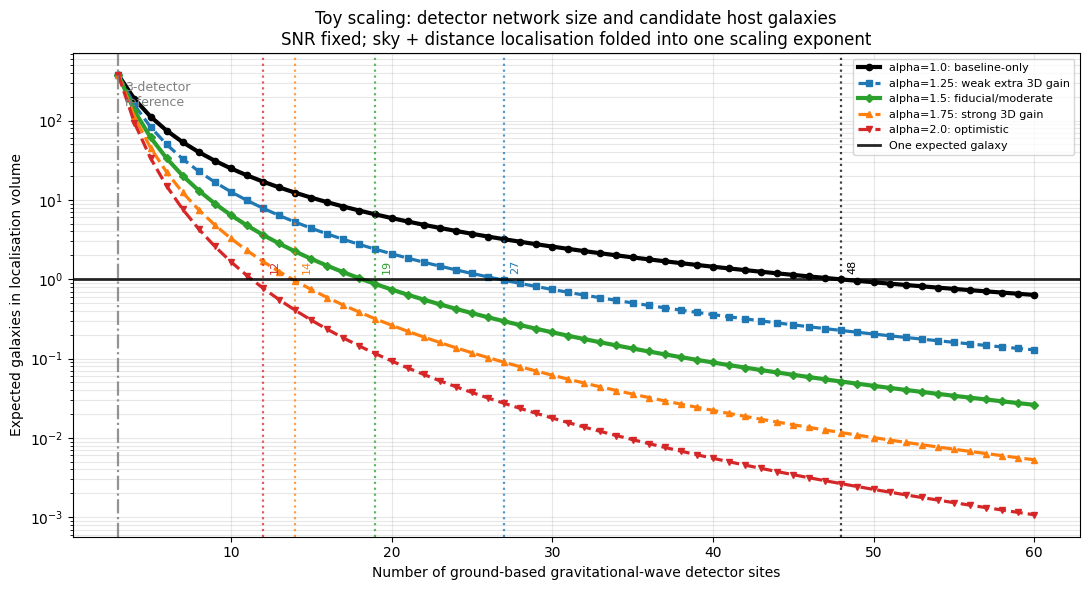

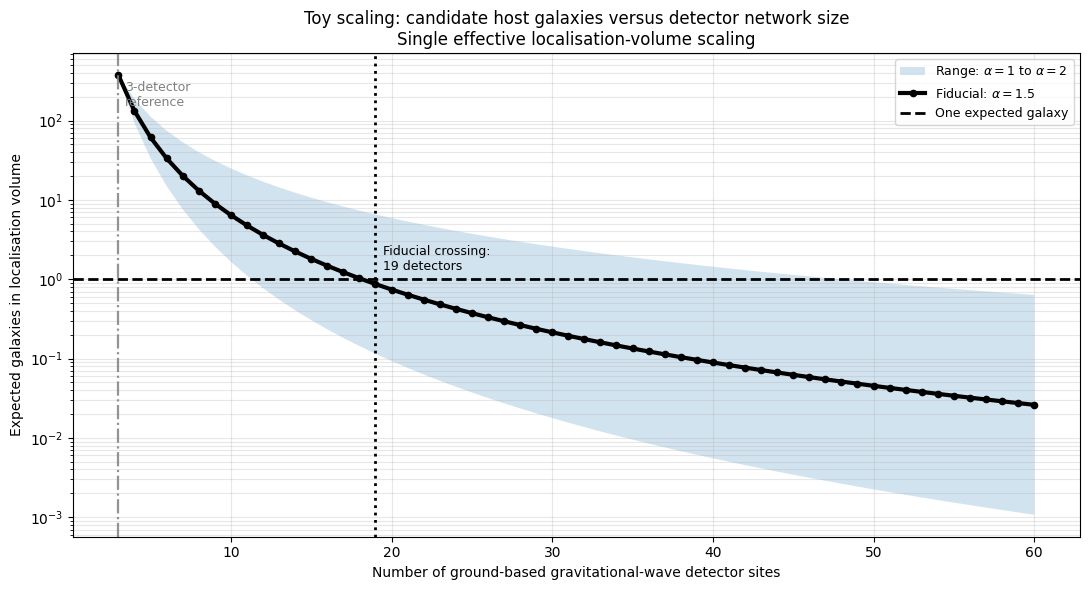

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Toy model:
# Expected number of galaxies versus number of GW detector sites
#
# This version folds sky localisation + distance uncertainty into
# one effective localisation-volume scaling.
#
# Model:
#   N_gal(N) = N_gal_ref / g_N^alpha
#
# where:
#   g_N = B_N / B_ref
#   B_N = N(N-1)/2
#
# alpha controls how efficiently extra baselines shrink the full
# 3D localisation volume.
#
# SNR is fixed in this model.
# ============================================================

# Reference case: GW190814-like localisation volume
N_ref = 3
N_gal_ref = 374  # observed-like galaxies in reference 3-detector volume

def n_baselines(N):
    """Number of pairwise baselines for N full detector sites."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector-site counts to explore
N_values = np.arange(3, 61)

# Alpha values:
# alpha = 1.0 : conservative; baseline count shrinks volume linearly
# alpha = 1.5 : fiducial/moderate; baselines also help 3D localisation somewhat
# alpha = 2.0 : optimistic; baselines strongly improve full 3D localisation
alpha_values = [1.0, 1.25, 1.5, 1.75, 2.0]
alpha_fiducial = 1.5

rows = []

for alpha in alpha_values:
    for N in N_values:
        B_N = n_baselines(N)
        g_N = B_N / B_ref

        expected_galaxies = N_gal_ref / (g_N ** alpha)

        rows.append({
            "n_detector_sites": N,
            "n_baselines": int(B_N),
            "baseline_gain_gN": g_N,
            "alpha": alpha,
            "expected_galaxies": expected_galaxies,
        })

toy_df = pd.DataFrame(rows)

# ============================================================
# Threshold table:
# first detector count where expected galaxies <= 1
# ============================================================

threshold_rows = []

for alpha in alpha_values:
    sub = toy_df[toy_df["alpha"] == alpha].copy()
    below = sub[sub["expected_galaxies"] <= 1]

    if len(below) > 0:
        first = below.iloc[0]
        threshold_rows.append({
            "alpha": alpha,
            "first_n_detector_sites_for_leq_1_galaxy": int(first["n_detector_sites"]),
            "baselines_at_threshold": int(first["n_baselines"]),
            "expected_galaxies_at_threshold": first["expected_galaxies"],
        })
    else:
        threshold_rows.append({
            "alpha": alpha,
            "first_n_detector_sites_for_leq_1_galaxy": np.nan,
            "baselines_at_threshold": np.nan,
            "expected_galaxies_at_threshold": np.nan,
        })

threshold_df = pd.DataFrame(threshold_rows)

print("First detector-site count reaching <= 1 expected galaxy:")
display(threshold_df)

# ============================================================
# Selected detector counts table
# ============================================================

selected_N = [3, 4, 5, 10, 15, 20, 30, 40, 48]

selected_table = (
    toy_df[toy_df["n_detector_sites"].isin(selected_N)]
    .pivot(
        index="n_detector_sites",
        columns="alpha",
        values="expected_galaxies"
    )
)

selected_table.columns = [f"alpha={c}" for c in selected_table.columns]

print("\nExpected galaxies for selected detector-site counts:")
display(selected_table)

# ============================================================
# Plot 1:
# Multiple alpha curves
# ============================================================

plt.figure(figsize=(11, 6))
ax = plt.gca()

curve_styles = {
    1.0:  {"color": "black",      "linewidth": 3.0, "linestyle": "-",  "marker": "o"},
    1.25: {"color": "tab:blue",   "linewidth": 2.3, "linestyle": "--", "marker": "s"},
    1.5:  {"color": "tab:green",  "linewidth": 3.0, "linestyle": "-",  "marker": "D"},
    1.75: {"color": "tab:orange", "linewidth": 2.3, "linestyle": "--", "marker": "^"},
    2.0:  {"color": "tab:red",    "linewidth": 2.3, "linestyle": "--", "marker": "v"},
}

alpha_labels = {
    1.0: "alpha=1.0: baseline-only",
    1.25: "alpha=1.25: weak extra 3D gain",
    1.5: "alpha=1.5: fiducial/moderate",
    1.75: "alpha=1.75: strong 3D gain",
    2.0: "alpha=2.0: optimistic",
}

for alpha in alpha_values:
    sub = toy_df[toy_df["alpha"] == alpha].copy()
    style = curve_styles[alpha]

    ax.plot(
        sub["n_detector_sites"],
        sub["expected_galaxies"],
        color=style["color"],
        linewidth=style["linewidth"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markersize=4.5,
        label=alpha_labels[alpha],
    )

    # Mark first crossing of one-galaxy line
    below_one = sub[sub["expected_galaxies"] <= 1]

    if len(below_one) > 0:
        first = below_one.iloc[0]
        n_thresh = first["n_detector_sites"]

        ax.axvline(
            n_thresh,
            color=style["color"],
            linestyle=":",
            linewidth=1.6,
            alpha=0.75,
        )

        ax.text(
            n_thresh + 0.4,
            1.15,
            f"{int(n_thresh)}",
            color=style["color"],
            fontsize=8,
            rotation=90,
            va="bottom",
            ha="left",
        )

# Reference lines
ax.axhline(
    1,
    color="black",
    linestyle="-",
    linewidth=2.0,
    alpha=0.85,
    label="One expected galaxy",
)

ax.axvline(
    N_ref,
    color="gray",
    linestyle="-.",
    linewidth=1.6,
    alpha=0.85,
)

ax.text(
    N_ref + 0.4,
    N_gal_ref * 0.85,
    "3-detector\nreference",
    fontsize=9,
    color="gray",
    va="top",
)

ax.set_yscale("log")
ax.set_xlabel("Number of ground-based gravitational-wave detector sites")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title(
    "Toy scaling: detector network size and candidate host galaxies\n"
    "SNR fixed; sky + distance localisation folded into one scaling exponent"
)

ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# Plot 2:
# Cleaner version: one fiducial curve with uncertainty band
# ============================================================

alpha_low = 1.0
alpha_high = 2.0
alpha_mid = alpha_fiducial

sub_low = toy_df[toy_df["alpha"] == alpha_low].copy()
sub_high = toy_df[toy_df["alpha"] == alpha_high].copy()
sub_mid = toy_df[toy_df["alpha"] == alpha_mid].copy()

plt.figure(figsize=(11, 6))
ax = plt.gca()

# Shaded plausible range
ax.fill_between(
    sub_mid["n_detector_sites"],
    sub_high["expected_galaxies"],  # lower galaxy count, stronger scaling
    sub_low["expected_galaxies"],   # higher galaxy count, weaker scaling
    alpha=0.2,
    label=r"Range: $\alpha=1$ to $\alpha=2$",
)

# Fiducial curve
ax.plot(
    sub_mid["n_detector_sites"],
    sub_mid["expected_galaxies"],
    color="black",
    linewidth=3.0,
    marker="o",
    markersize=4.5,
    label=fr"Fiducial: $\alpha={alpha_mid}$",
)

# One-galaxy threshold
ax.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="One expected galaxy",
)

# Reference 3-detector line
ax.axvline(
    N_ref,
    color="gray",
    linestyle="-.",
    linewidth=1.6,
    alpha=0.85,
)

ax.text(
    N_ref + 0.4,
    N_gal_ref * 0.85,
    "3-detector\nreference",
    fontsize=9,
    color="gray",
    va="top",
)

# Fiducial threshold
below_one_mid = sub_mid[sub_mid["expected_galaxies"] <= 1]

if len(below_one_mid) > 0:
    first_mid = below_one_mid.iloc[0]
    n_thresh_mid = int(first_mid["n_detector_sites"])

    ax.axvline(
        n_thresh_mid,
        color="black",
        linestyle=":",
        linewidth=2.0,
    )

    ax.text(
        n_thresh_mid + 0.5,
        1.2,
        f"Fiducial crossing:\n{n_thresh_mid} detectors",
        fontsize=9,
        va="bottom",
    )

ax.set_yscale("log")
ax.set_xlabel("Number of ground-based gravitational-wave detector sites")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title(
    "Toy scaling: candidate host galaxies versus detector network size\n"
    "Single effective localisation-volume scaling"
)

ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


Fetching GWTC-1-confident as GWTC-1...
  Events listed: 11

Fetching GWTC-2.1-confident as GWTC-2...
  Events listed: 54
  Skipping GW190514_065416: 502 Server Error: Proxy Error for url: https://gwosc.org/api/v2/event-versions/GW190514_065416-v2/parameters?format=json

Fetching GWTC-3-confident as GWTC-3...
  Events listed: 35

Fetching GWTC-4.0 as GWTC-4.0...
  Events listed: 129
  Skipping GW230630_070659: 502 Server Error: Proxy Error for url: https://gwosc.org/api/v2/event-versions/GW230630_070659-v1/parameters?format=json
  Skipping GW230628_231200: 502 Server Error: Proxy Error for url: https://gwosc.org/api/v2/event-versions/GW230628_231200-v1/parameters?format=json

Raw pulled rows:


,source_plot_label,n_rows,n_with_sky_area
0,GWTC-1,11,11
1,GWTC-2,53,53
2,GWTC-3,35,35
3,GWTC-4.0,85,0



Usable unique rows:


,release,n_events,n_with_sky_area,median_distance
0,GWTC-1,11,11,990.0
1,GWTC-2,43,43,2070.0
2,GWTC-3,35,35,1620.0
3,GWTC-4.0,85,0,2800.0



Events used in empirical fit:


...


Sky-area fit:


,term,coefficient,std_error
0,intercept,0.349350,0.495653
1,log_distance,0.780336,0.152900
2,log_baseline_gain,-1.025899,0.299669



Distance-width fit:


,term,coefficient,std_error
0,intercept,-0.748126,0.098849
1,log_distance,1.230243,0.030493
2,log_baseline_gain,-0.015671,0.059764



Empirical scaling exponents
---------------------------
a_sky  = 1.026  where sky area ∝ g^(-a)
b_dist = 0.016  where distance width ∝ g^(-b)
alpha = a_sky + b_dist = 1.042

Bootstrap alpha estimate:
median alpha = 1.040
16th–84th percentile = 0.778 to 1.310


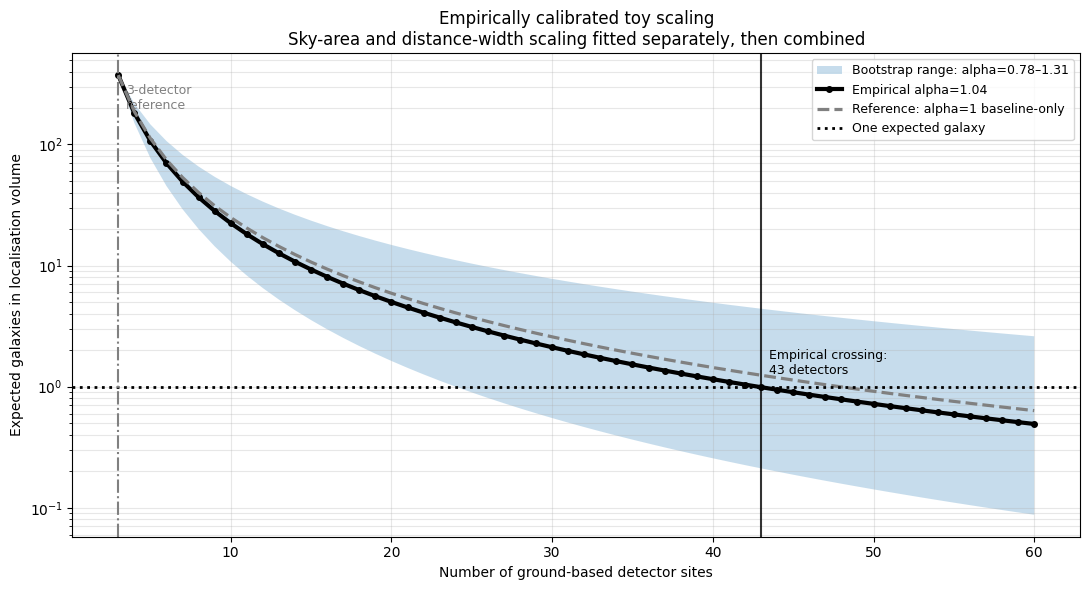

In [7]:
# ============================================================
# SELF-CONTAINED RECOVERY CELL
#
# Rebuilds a minimal GWTC dataframe from GWOSC, then fits empirical
# localisation-volume scaling with detector baseline count.
#
# Output:
#   det_df
#   empirical
#   alpha estimate
#   expected-galaxy scaling plot
#
# Note:
#   If GWTC-4.0 sky_area is not exposed in the API, those events
#   may be skipped in the alpha fit unless you separately fill sky areas
#   from skymaps.
# ============================================================

# If needed in a fresh notebook:
# %pip install -q requests pandas numpy matplotlib astropy

import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from astropy.time import Time


# ------------------------------------------------------------
# 1. Basic API helpers
# ------------------------------------------------------------

def get_json(url, timeout=90):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()


def json_url(url):
    if "format=" in url:
        return re.sub(r"format=[^&]+", "format=json", url)
    if "?" in url:
        return url + "&format=json"
    return url + "?format=json"


def fetch_all_pages(url):
    results = []
    next_url = url

    while next_url:
        data = get_json(next_url)
        results.extend(data.get("results", []))
        next_url = data.get("next")

    return results


def safe_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan


# ------------------------------------------------------------
# 2. Parameter helpers
# ------------------------------------------------------------

def param_list_to_dict(param_list):
    out = {}
    for p in param_list or []:
        name = p.get("name")
        if name:
            out[name] = p
    return out


def choose_preferred_pe_parameter_set(parameter_sets):
    """
    Choose a PE parameter set.
    Preference:
      1. PE + is_preferred
      2. PE with both sky_area and luminosity_distance
      3. PE with luminosity_distance
      4. first PE
    """
    pe_sets = [
        p for p in parameter_sets
        if p.get("pipeline_type") == "pe"
    ]

    if not pe_sets:
        return None

    preferred = [p for p in pe_sets if p.get("is_preferred") is True]
    if preferred:
        return preferred[0]

    with_sky_and_dist = []
    with_dist = []

    for p in pe_sets:
        pdict = param_list_to_dict(p.get("parameters", []))

        if "luminosity_distance" in pdict:
            with_dist.append(p)

        if "luminosity_distance" in pdict and "sky_area" in pdict:
            with_sky_and_dist.append(p)

    if with_sky_and_dist:
        return with_sky_and_dist[0]

    if with_dist:
        return with_dist[0]

    return pe_sets[0]


def get_param_best_lower_upper(pdict, key):
    if key not in pdict:
        return np.nan, np.nan, np.nan

    p = pdict[key]

    best = safe_float(p.get("best"))
    lower = safe_float(p.get("lower_error"))
    upper = safe_float(p.get("upper_error"))

    return best, lower, upper


def distance_bounds_from_params(pdict):
    """
    GWOSC usually stores:
      best = median
      lower_error = negative offset
      upper_error = positive offset
    """
    d, lo, hi = get_param_best_lower_upper(pdict, "luminosity_distance")

    if not np.isfinite(d) or not np.isfinite(lo) or not np.isfinite(hi):
        return np.nan, np.nan, np.nan

    d_low = d + lo if lo < 0 else d - lo
    d_high = d + hi if hi > 0 else d - hi

    if d_low <= 0 or d_high <= 0 or d_high <= d_low:
        return d, np.nan, np.nan

    return d, d_low, d_high


def sky_area_from_params(pdict):
    for key in ["sky_area", "area_90", "Area90", "area90"]:
        if key in pdict:
            val, _, _ = get_param_best_lower_upper(pdict, key)
            if np.isfinite(val):
                return val
    return np.nan


# ------------------------------------------------------------
# 3. Date and detector helpers
# ------------------------------------------------------------

def detection_datetime_from_event_name(event_name):
    """
    Parses names like GW190814 or GW231123_135430.
    """
    m = re.match(r"GW(\d{2})(\d{2})(\d{2})(?:_(\d{2})(\d{2})(\d{2}))?", str(event_name))

    if not m:
        return pd.NaT

    yy, mm, dd, hh, minute, ss = m.groups()

    year = 2000 + int(yy)
    month = int(mm)
    day = int(dd)
    hour = int(hh) if hh else 0
    minute = int(minute) if minute else 0
    second = int(ss) if ss else 0

    try:
        return pd.Timestamp(datetime(year, month, day, hour, minute, second))
    except Exception:
        return pd.NaT


def detection_datetime_from_gps(gps):
    if not np.isfinite(gps):
        return pd.NaT
    try:
        return pd.Timestamp(Time(gps, format="gps").datetime)
    except Exception:
        return pd.NaT


def choose_detection_datetime(event_name, gps):
    name_dt = detection_datetime_from_event_name(event_name)
    gps_dt = detection_datetime_from_gps(gps)

    if pd.notna(name_dt) and pd.notna(gps_dt):
        # Use GPS if it broadly agrees with the event-name date.
        if abs((gps_dt - name_dt).total_seconds()) < 5 * 24 * 3600:
            return gps_dt
        return name_dt

    if pd.notna(gps_dt):
        return gps_dt

    return name_dt


def release_bucket_from_detection_date(dt):
    if pd.isna(dt):
        return "Unknown"

    dt = pd.Timestamp(dt)

    if pd.Timestamp("2015-09-12") <= dt <= pd.Timestamp("2017-08-25"):
        return "GWTC-1"

    if pd.Timestamp("2019-04-01") <= dt <= pd.Timestamp("2019-10-01"):
        return "GWTC-2"

    if pd.Timestamp("2019-11-01") <= dt <= pd.Timestamp("2020-03-27"):
        return "GWTC-3"

    if pd.Timestamp("2023-05-24") <= dt <= pd.Timestamp("2024-01-16"):
        return "GWTC-4.0"

    return "Other"


def count_detectors(detector_value):
    if detector_value is None or (isinstance(detector_value, float) and np.isnan(detector_value)):
        return np.nan

    if isinstance(detector_value, list):
        detectors = detector_value
    else:
        detectors = re.findall(r"\b(H1|L1|V1|K1|G1)\b", str(detector_value))

    detectors = set(detectors)
    return len(detectors) if detectors else np.nan


# ------------------------------------------------------------
# 4. Pull catalogues
# ------------------------------------------------------------

CATALOG_SPECS = [
    ("GWTC-1",   "GWTC-1-confident"),
    ("GWTC-2",   "GWTC-2.1-confident"),
    ("GWTC-3",   "GWTC-3-confident"),
    ("GWTC-4.0", "GWTC-4.0"),
]

rows = []

for plot_label, catalog_name in CATALOG_SPECS:
    print(f"\nFetching {catalog_name} as {plot_label}...")

    events_url = (
        f"https://gwosc.org/api/v2/catalogs/{catalog_name}/events"
        f"?format=json&pagesize=300"
    )

    try:
        events = fetch_all_pages(events_url)
        print(f"  Events listed: {len(events)}")
    except Exception as e:
        print(f"  Could not fetch {catalog_name}: {e}")
        continue

    for ev in events:
        event_name = ev.get("name")
        detail_url = ev.get("detail_url")

        if event_name is None or detail_url is None:
            continue

        try:
            detail = get_json(json_url(detail_url))

            gps = safe_float(ev.get("gps"))
            if not np.isfinite(gps):
                gps = safe_float(detail.get("gps"))
            if not np.isfinite(gps):
                gps = safe_float(detail.get("GPS"))

            event_date = choose_detection_datetime(event_name, gps)
            date_bucket = release_bucket_from_detection_date(event_date)

            detectors = detail.get("detectors")
            n_detectors = count_detectors(detectors)

            params_url = detail.get("parameters_url")

            if not params_url:
                continue

            param_sets_json = get_json(json_url(params_url))
            param_sets = param_sets_json.get("results", [])

            pe = choose_preferred_pe_parameter_set(param_sets)

            if pe is None:
                continue

            pdict = param_list_to_dict(pe.get("parameters", []))

            d_med, d_low, d_high = distance_bounds_from_params(pdict)
            sky_area_deg2 = sky_area_from_params(pdict)

            if not np.isfinite(d_low) or not np.isfinite(d_high):
                continue

            rows.append({
                "event_name": event_name,
                "source_catalog": catalog_name,
                "source_plot_label": plot_label,
                "date_bucket": date_bucket,
                "event_date": event_date,
                "gps": gps,
                "detectors": ",".join(detectors) if isinstance(detectors, list) else str(detectors),
                "n_detectors": n_detectors,
                "pe_name": pe.get("name"),
                "sky_area_deg2": sky_area_deg2,
                "d_median_mpc": d_med,
                "d_low_mpc": d_low,
                "d_high_mpc": d_high,
                "distance_width_mpc": d_high - d_low,
            })

        except Exception as e:
            print(f"  Skipping {event_name}: {e}")

        time.sleep(0.02)


raw_events = pd.DataFrame(rows)

if len(raw_events) == 0:
    raise RuntimeError("No GWTC event rows pulled.")

print("\nRaw pulled rows:")
display(
    raw_events
    .groupby("source_plot_label")
    .agg(
        n_rows=("event_name", "count"),
        n_with_sky_area=("sky_area_deg2", lambda x: np.isfinite(x).sum()),
    )
    .reset_index()
)

# ------------------------------------------------------------
# 5. Deduplicate by event name
# ------------------------------------------------------------

raw_events["bucket_match"] = raw_events["source_plot_label"] == raw_events["date_bucket"]

raw_events["source_rank"] = raw_events["source_plot_label"].map({
    "GWTC-1": 1,
    "GWTC-2": 2,
    "GWTC-3": 3,
    "GWTC-4.0": 4,
}).fillna(99)

usable = (
    raw_events
    .sort_values(
        ["event_name", "bucket_match", "source_rank"],
        ascending=[True, False, True]
    )
    .drop_duplicates("event_name", keep="first")
    .copy()
)

usable["plot_label"] = usable["date_bucket"]
usable.loc[~usable["plot_label"].isin(["GWTC-1", "GWTC-2", "GWTC-3", "GWTC-4.0"]), "plot_label"] = (
    usable.loc[~usable["plot_label"].isin(["GWTC-1", "GWTC-2", "GWTC-3", "GWTC-4.0"]), "source_plot_label"]
)

det_df = usable.copy()
det_df["release"] = det_df["plot_label"].astype(str)

print("\nUsable unique rows:")
display(
    det_df
    .groupby("release")
    .agg(
        n_events=("event_name", "count"),
        n_with_sky_area=("sky_area_deg2", lambda x: np.isfinite(x).sum()),
        median_distance=("d_median_mpc", "median"),
    )
    .reset_index()
)


# ============================================================
# EMPIRICAL SCALING FIT
# ============================================================

# ------------------------------------------------------------
# 6. Prepare empirical dataset
# ------------------------------------------------------------

empirical = det_df[
    np.isfinite(det_df["n_detectors"]) &
    (det_df["n_detectors"] >= 2) &
    np.isfinite(det_df["sky_area_deg2"]) &
    np.isfinite(det_df["distance_width_mpc"]) &
    np.isfinite(det_df["d_median_mpc"]) &
    (det_df["sky_area_deg2"] > 0) &
    (det_df["distance_width_mpc"] > 0) &
    (det_df["d_median_mpc"] > 0)
].copy()

def n_baselines_from_detectors(n):
    return n * (n - 1) / 2

empirical["n_baselines"] = n_baselines_from_detectors(empirical["n_detectors"])
empirical["baseline_gain_g"] = empirical["n_baselines"] / 3.0

empirical["log_distance"] = np.log10(empirical["d_median_mpc"])
empirical["log_baseline_gain"] = np.log10(empirical["baseline_gain_g"])
empirical["log_sky_area"] = np.log10(empirical["sky_area_deg2"])
empirical["log_distance_width"] = np.log10(empirical["distance_width_mpc"])

print("\nEvents used in empirical fit:")
display(
    empirical
    .groupby(["release", "n_detectors"])
    .agg(
        n=("event_name", "count"),
        median_distance_mpc=("d_median_mpc", "median"),
        median_sky_area_deg2=("sky_area_deg2", "median"),
        median_distance_width_mpc=("distance_width_mpc", "median"),
    )
    .reset_index()
)

if len(empirical) < 10:
    raise RuntimeError(
        f"Only {len(empirical)} usable events for fit. "
        "Likely sky_area is missing for many events. "
        "You may need the skymap-archive fill step for GWTC-4.0."
    )


# ------------------------------------------------------------
# 7. OLS fit helper
# ------------------------------------------------------------

def fit_ols(y, X, column_names):
    X_mat = np.asarray(X, dtype=float)
    y_vec = np.asarray(y, dtype=float)

    coef, residuals, rank, s = np.linalg.lstsq(X_mat, y_vec, rcond=None)

    y_hat = X_mat @ coef
    resid = y_vec - y_hat

    n = len(y_vec)
    p = X_mat.shape[1]

    sigma2 = np.sum(resid**2) / max(n - p, 1)

    try:
        cov = sigma2 * np.linalg.inv(X_mat.T @ X_mat)
        se = np.sqrt(np.diag(cov))
    except Exception:
        se = np.full(p, np.nan)

    summary = pd.DataFrame({
        "term": column_names,
        "coefficient": coef,
        "std_error": se,
    })

    return coef, summary, y_hat, resid


# Model:
# log(quantity) = c + p log(distance) + beta log(baseline_gain)
X = np.column_stack([
    np.ones(len(empirical)),
    empirical["log_distance"].values,
    empirical["log_baseline_gain"].values,
])

terms = ["intercept", "log_distance", "log_baseline_gain"]

coef_sky, summary_sky, yhat_sky, resid_sky = fit_ols(
    empirical["log_sky_area"].values,
    X,
    terms
)

coef_dist, summary_dist, yhat_dist, resid_dist = fit_ols(
    empirical["log_distance_width"].values,
    X,
    terms
)

print("\nSky-area fit:")
display(summary_sky)

print("\nDistance-width fit:")
display(summary_dist)

# Convert coefficients to scaling exponents
beta_sky = coef_sky[2]
beta_dist = coef_dist[2]

a_sky = -beta_sky
b_dist = -beta_dist
alpha_empirical = a_sky + b_dist

print("\nEmpirical scaling exponents")
print("---------------------------")
print(f"a_sky  = {a_sky:.3f}  where sky area ∝ g^(-a)")
print(f"b_dist = {b_dist:.3f}  where distance width ∝ g^(-b)")
print(f"alpha = a_sky + b_dist = {alpha_empirical:.3f}")

if alpha_empirical <= 0:
    print(
        "\nWARNING: alpha <= 0. This catalogue sample does not show localisation "
        "volume shrinking with baseline count after controlling for distance. "
        "That may reflect selection effects, sparse 3+/4-detector data, detector "
        "sensitivity differences, or missing confounders such as SNR."
    )


# ------------------------------------------------------------
# 8. Bootstrap alpha uncertainty
# ------------------------------------------------------------

rng = np.random.default_rng(42)
n_boot = 1000
alpha_boot = []

for _ in range(n_boot):
    sample = empirical.sample(
        n=len(empirical),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000_000))
    )

    Xb = np.column_stack([
        np.ones(len(sample)),
        sample["log_distance"].values,
        sample["log_baseline_gain"].values,
    ])

    try:
        coef_sky_b, _, _, _ = fit_ols(
            sample["log_sky_area"].values,
            Xb,
            terms
        )

        coef_dist_b, _, _, _ = fit_ols(
            sample["log_distance_width"].values,
            Xb,
            terms
        )

        alpha_b = -(coef_sky_b[2] + coef_dist_b[2])

        if np.isfinite(alpha_b):
            alpha_boot.append(alpha_b)

    except Exception:
        pass

alpha_boot = np.asarray(alpha_boot)

alpha_med = np.nanmedian(alpha_boot)
alpha_lo = np.nanquantile(alpha_boot, 0.16)
alpha_hi = np.nanquantile(alpha_boot, 0.84)

print("\nBootstrap alpha estimate:")
print(f"median alpha = {alpha_med:.3f}")
print(f"16th–84th percentile = {alpha_lo:.3f} to {alpha_hi:.3f}")


# ------------------------------------------------------------
# 9. Plot expected galaxies vs detector count
# ------------------------------------------------------------

N_gal_ref = 374
N_ref = 3

def n_baselines(N):
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

N_values = np.arange(3, 61)
g_values = n_baselines(N_values) / B_ref

N_gal_alpha_med = N_gal_ref / (g_values ** alpha_med)
N_gal_alpha_lo = N_gal_ref / (g_values ** alpha_lo)
N_gal_alpha_hi = N_gal_ref / (g_values ** alpha_hi)

N_gal_baseline_only = N_gal_ref / g_values  # alpha = 1 reference

plt.figure(figsize=(11, 6))
ax = plt.gca()

# Depending on sign/order of alpha bounds, sort the band
lower_band = np.minimum(N_gal_alpha_lo, N_gal_alpha_hi)
upper_band = np.maximum(N_gal_alpha_lo, N_gal_alpha_hi)

ax.fill_between(
    N_values,
    lower_band,
    upper_band,
    alpha=0.25,
    label=f"Bootstrap range: alpha={alpha_lo:.2f}–{alpha_hi:.2f}"
)

ax.plot(
    N_values,
    N_gal_alpha_med,
    color="black",
    linewidth=3,
    marker="o",
    markersize=4,
    label=f"Empirical alpha={alpha_med:.2f}"
)

ax.plot(
    N_values,
    N_gal_baseline_only,
    color="gray",
    linewidth=2.3,
    linestyle="--",
    label="Reference: alpha=1 baseline-only"
)

ax.axhline(
    1,
    color="black",
    linestyle=":",
    linewidth=2,
    label="One expected galaxy"
)

ax.axvline(
    3,
    color="gray",
    linestyle="-.",
    linewidth=1.5
)

ax.text(
    3.5,
    N_gal_ref * 0.85,
    "3-detector\nreference",
    color="gray",
    fontsize=9,
    va="top"
)

below_one = N_values[N_gal_alpha_med <= 1]

if len(below_one) > 0:
    n_thresh = below_one[0]

    ax.axvline(
        n_thresh,
        color="black",
        linestyle="-",
        linewidth=1.5,
        alpha=0.8
    )

    ax.text(
        n_thresh + 0.5,
        1.2,
        f"Empirical crossing:\n{n_thresh} detectors",
        fontsize=9,
        va="bottom"
    )
else:
    ax.text(
        30,
        2,
        "Empirical curve does not\nreach one galaxy by 60 detectors",
        fontsize=9
    )

ax.set_yscale("log")
ax.set_xlabel("Number of ground-based detector sites")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title(
    "Empirically calibrated toy scaling\n"
    "Sky-area and distance-width scaling fitted separately, then combined"
)

ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Recovery/setup cell for empirical localisation scaling
#
# This creates det_df from whatever GWTC dataframe currently exists.
# Run this before the empirical alpha-scaling cell.
# ============================================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Find an existing GWTC dataframe
# ------------------------------------------------------------

candidate_names = ["det_df", "usable", "usable_raw", "raw_events", "events_df", "all_events"]

source_name = None
source_df = None

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            source_name = name
            source_df = obj.copy()
            break

if source_df is None:
    raise RuntimeError(
        "No GWTC dataframe found in memory.\n\n"
        "You need to rerun the GWTC localisation-volume pull/plotting cell first — "
        "the one that creates `usable` or `raw_events`.\n\n"
        "After that, rerun this recovery/setup cell."
    )

print(f"Using dataframe: {source_name}")
print(f"Rows: {len(source_df)}")
print("Columns:")
print(source_df.columns.tolist())

# ------------------------------------------------------------
# 2. Standardise release labels
# ------------------------------------------------------------

det_df = source_df.copy()

if "release" not in det_df.columns:
    if "plot_label" in det_df.columns:
        det_df["release"] = det_df["plot_label"].astype(str)
    elif "source_plot_label" in det_df.columns:
        det_df["release"] = det_df["source_plot_label"].astype(str)
    elif "release_label" in det_df.columns:
        det_df["release"] = det_df["release_label"].astype(str)
    else:
        det_df["release"] = "Unknown"

# ------------------------------------------------------------
# 3. Create distance width if needed
# ------------------------------------------------------------

if "distance_width_mpc" not in det_df.columns:
    if {"d_high_mpc", "d_low_mpc"}.issubset(det_df.columns):
        det_df["distance_width_mpc"] = det_df["d_high_mpc"] - det_df["d_low_mpc"]
    else:
        raise RuntimeError(
            "Cannot create distance_width_mpc because d_high_mpc and d_low_mpc are missing."
        )

# ------------------------------------------------------------
# 4. Create detector count if needed
# ------------------------------------------------------------

def count_detectors(detector_string):
    """
    Count unique GW detectors in a detector string.
    Handles strings like 'H1,L1,V1' or lists if present.
    """
    if pd.isna(detector_string):
        return np.nan

    text = str(detector_string)

    detectors = re.findall(r"\b(H1|L1|V1|K1|G1)\b", text)

    return len(set(detectors)) if detectors else np.nan

if "n_detectors" not in det_df.columns:
    if "detectors" in det_df.columns:
        det_df["n_detectors"] = det_df["detectors"].apply(count_detectors)
    else:
        raise RuntimeError(
            "Cannot create n_detectors because no `detectors` column exists."
        )

# ------------------------------------------------------------
# 5. Basic cleanup / sanity check
# ------------------------------------------------------------

required = [
    "event_name",
    "release",
    "n_detectors",
    "sky_area_deg2",
    "d_median_mpc",
    "distance_width_mpc",
]

missing = [c for c in required if c not in det_df.columns]

if missing:
    raise RuntimeError(
        f"det_df is missing required columns: {missing}\n"
        "You probably need to rerun the fuller GWTC pull cell."
    )

det_df = det_df[
    np.isfinite(det_df["n_detectors"]) &
    np.isfinite(det_df["sky_area_deg2"]) &
    np.isfinite(det_df["d_median_mpc"]) &
    np.isfinite(det_df["distance_width_mpc"]) &
    (det_df["sky_area_deg2"] > 0) &
    (det_df["d_median_mpc"] > 0) &
    (det_df["distance_width_mpc"] > 0)
].copy()

print("\nRecovered det_df:")
print(det_df.shape)

display(
    det_df
    .groupby(["release", "n_detectors"])
    .agg(
        n=("event_name", "count"),
        median_distance_mpc=("d_median_mpc", "median"),
        median_sky_area_deg2=("sky_area_deg2", "median"),
        median_distance_width_mpc=("distance_width_mpc", "median"),
    )
    .reset_index()
)

RuntimeError: No GWTC dataframe found in memory.

You need to rerun the GWTC localisation-volume pull/plotting cell first — the one that creates `usable` or `raw_events`.

After that, rerun this recovery/setup cell.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Empirical calibration of localisation-volume scaling
#
# Goal:
#   Fit how sky area and distance width scale with baseline count
#   using actual GWTC catalogue data.
#
# Model:
#   Omega    ∝ g_N^(-a)
#   Delta d ∝ g_N^(-b)
#
# Then:
#   V ∝ Omega * Delta d ∝ g_N^(-(a+b))
#
# and:
#   N_gal(N) = 374 / g_N^(a+b)
#
# ============================================================

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

# Use det_df if it exists, otherwise fall back to usable
try:
    empirical = det_df.copy()
except NameError:
    empirical = usable.copy()

# Ensure release column exists
if "release" not in empirical.columns:
    empirical["release"] = empirical["plot_label"].astype(str)

# Ensure distance width exists
if "distance_width_mpc" not in empirical.columns:
    empirical["distance_width_mpc"] = empirical["d_high_mpc"] - empirical["d_low_mpc"]

# Ensure detector count exists
if "n_detectors" not in empirical.columns:
    raise RuntimeError(
        "n_detectors column not found. Run the detector-count analysis first."
    )

# Exclude one-detector events because they have zero baselines.
# This model is explicitly a baseline-count model.
empirical = empirical[
    np.isfinite(empirical["n_detectors"]) &
    (empirical["n_detectors"] >= 2) &
    np.isfinite(empirical["sky_area_deg2"]) &
    np.isfinite(empirical["distance_width_mpc"]) &
    np.isfinite(empirical["d_median_mpc"]) &
    (empirical["sky_area_deg2"] > 0) &
    (empirical["distance_width_mpc"] > 0) &
    (empirical["d_median_mpc"] > 0)
].copy()

def n_baselines_from_detectors(n):
    return n * (n - 1) / 2

# Baseline count and gain relative to a 3-detector network
empirical["n_baselines"] = n_baselines_from_detectors(empirical["n_detectors"])
empirical["baseline_gain_g"] = empirical["n_baselines"] / 3.0

# Logs
empirical["log_distance"] = np.log10(empirical["d_median_mpc"])
empirical["log_baseline_gain"] = np.log10(empirical["baseline_gain_g"])
empirical["log_sky_area"] = np.log10(empirical["sky_area_deg2"])
empirical["log_distance_width"] = np.log10(empirical["distance_width_mpc"])

print("Events used in empirical fit:")
display(
    empirical
    .groupby(["release", "n_detectors"])
    .agg(
        n=("event_name", "count"),
        median_distance_mpc=("d_median_mpc", "median"),
        median_sky_area_deg2=("sky_area_deg2", "median"),
        median_distance_width_mpc=("distance_width_mpc", "median"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Simple OLS helper
# ------------------------------------------------------------

def fit_ols(y, X, column_names):
    """
    Simple OLS using numpy.
    Returns coefficients and a basic summary dataframe.
    """
    X_mat = np.asarray(X, dtype=float)
    y_vec = np.asarray(y, dtype=float)

    coef, residuals, rank, s = np.linalg.lstsq(X_mat, y_vec, rcond=None)

    y_hat = X_mat @ coef
    resid = y_vec - y_hat

    n = len(y_vec)
    p = X_mat.shape[1]

    sigma2 = np.sum(resid**2) / max(n - p, 1)
    cov = sigma2 * np.linalg.inv(X_mat.T @ X_mat)
    se = np.sqrt(np.diag(cov))

    summary = pd.DataFrame({
        "term": column_names,
        "coefficient": coef,
        "std_error": se,
    })

    return coef, summary, y_hat, resid

# Design matrix:
# log(quantity) = c + p log(distance) + beta log(baseline_gain)
#
# We include log(distance) because more distant events naturally have larger
# sky areas and broader distance intervals.
X = np.column_stack([
    np.ones(len(empirical)),
    empirical["log_distance"].values,
    empirical["log_baseline_gain"].values,
])

terms = ["intercept", "log_distance", "log_baseline_gain"]

# Fit sky-area scaling
coef_sky, summary_sky, yhat_sky, resid_sky = fit_ols(
    empirical["log_sky_area"].values,
    X,
    terms
)

# Fit distance-width scaling
coef_dist, summary_dist, yhat_dist, resid_dist = fit_ols(
    empirical["log_distance_width"].values,
    X,
    terms
)

print("\nSky-area fit:")
display(summary_sky)

print("\nDistance-width fit:")
display(summary_dist)

# ------------------------------------------------------------
# 3. Convert regression coefficients into scaling exponents
# ------------------------------------------------------------

# In the fit:
#   log sky_area = ... + beta_sky * log(g)
#
# If sky_area ∝ g^(-a), then:
#   beta_sky = -a
#
# Similarly:
#   beta_dist = -b

beta_sky = coef_sky[2]
beta_dist = coef_dist[2]

a_sky = -beta_sky
b_dist = -beta_dist
alpha_empirical = a_sky + b_dist

print("\nEmpirical scaling exponents")
print("---------------------------")
print(f"a_sky  = {-beta_sky:.3f}  where sky area ∝ g^(-a)")
print(f"b_dist = {-beta_dist:.3f}  where distance width ∝ g^(-b)")
print(f"alpha = a_sky + b_dist = {alpha_empirical:.3f}")

if alpha_empirical <= 0:
    print(
        "\nWARNING: The fitted alpha is <= 0. "
        "That means this catalogue sample does not show localisation volume "
        "shrinking with baseline count after controlling for distance. "
        "This may reflect selection effects, sparse 3+/4-detector data, "
        "or detector-count confounding."
    )

# ------------------------------------------------------------
# 4. Bootstrap uncertainty on alpha
# ------------------------------------------------------------

rng = np.random.default_rng(42)
n_boot = 1000
alpha_boot = []

for _ in range(n_boot):
    sample = empirical.sample(
        n=len(empirical),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000_000))
    )

    Xb = np.column_stack([
        np.ones(len(sample)),
        sample["log_distance"].values,
        sample["log_baseline_gain"].values,
    ])

    try:
        coef_sky_b, _, _, _ = fit_ols(
            sample["log_sky_area"].values,
            Xb,
            terms
        )

        coef_dist_b, _, _, _ = fit_ols(
            sample["log_distance_width"].values,
            Xb,
            terms
        )

        alpha_b = -(coef_sky_b[2] + coef_dist_b[2])

        if np.isfinite(alpha_b):
            alpha_boot.append(alpha_b)

    except Exception:
        pass

alpha_boot = np.asarray(alpha_boot)

alpha_med = np.nanmedian(alpha_boot)
alpha_lo = np.nanquantile(alpha_boot, 0.16)
alpha_hi = np.nanquantile(alpha_boot, 0.84)

print("\nBootstrap alpha estimate:")
print(f"median alpha = {alpha_med:.3f}")
print(f"16th–84th percentile = {alpha_lo:.3f} to {alpha_hi:.3f}")

# ------------------------------------------------------------
# 5. Plot expected galaxies vs detector count using fitted alpha
# ------------------------------------------------------------

N_gal_ref = 374
N_ref = 3

def n_baselines(N):
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

N_values = np.arange(3, 61)
g_values = n_baselines(N_values) / B_ref

# If empirical alpha is pathological, still plot it, but also plot alpha=1
N_gal_alpha_med = N_gal_ref / (g_values ** alpha_med)
N_gal_alpha_lo = N_gal_ref / (g_values ** alpha_lo)
N_gal_alpha_hi = N_gal_ref / (g_values ** alpha_hi)

N_gal_baseline_only = N_gal_ref / g_values  # alpha = 1 reference

plt.figure(figsize=(11, 6))
ax = plt.gca()

# Bootstrap range
ax.fill_between(
    N_values,
    N_gal_alpha_hi,
    N_gal_alpha_lo,
    alpha=0.25,
    label=f"Bootstrap range: alpha={alpha_lo:.2f}–{alpha_hi:.2f}"
)

# Empirical median alpha
ax.plot(
    N_values,
    N_gal_alpha_med,
    color="black",
    linewidth=3,
    marker="o",
    markersize=4,
    label=f"Empirical alpha={alpha_med:.2f}"
)

# Baseline-only alpha=1 reference
ax.plot(
    N_values,
    N_gal_baseline_only,
    color="gray",
    linewidth=2.3,
    linestyle="--",
    label="Reference: alpha=1 baseline-only"
)

# One-galaxy threshold
ax.axhline(
    1,
    color="black",
    linestyle=":",
    linewidth=2,
    label="One expected galaxy"
)

# 3-detector reference
ax.axvline(
    3,
    color="gray",
    linestyle="-.",
    linewidth=1.5
)

ax.text(
    3.5,
    N_gal_ref * 0.85,
    "3-detector\nreference",
    color="gray",
    fontsize=9,
    va="top"
)

# Mark threshold for empirical median if it reaches <= 1
below_one = N_values[N_gal_alpha_med <= 1]

if len(below_one) > 0:
    n_thresh = below_one[0]

    ax.axvline(
        n_thresh,
        color="black",
        linestyle="-",
        linewidth=1.5,
        alpha=0.8
    )

    ax.text(
        n_thresh + 0.5,
        1.2,
        f"Empirical crossing:\n{n_thresh} detectors",
        fontsize=9,
        va="bottom"
    )
else:
    ax.text(
        35,
        2,
        "Empirical curve does not\nreach one galaxy by 60 detectors",
        fontsize=9
    )

ax.set_yscale("log")
ax.set_xlabel("Number of ground-based detector sites")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title(
    "Empirically calibrated toy scaling\n"
    "Sky-area and distance-width scaling fitted separately, then combined"
)

ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

NameError: name 'usable' is not defined